# Project 3 — Multi-Class Classification and Error Analysis

This notebook studies multi-class classification using the Wine dataset. The focus is on class-wise metrics, confusion patterns, model behavior, separability, and hyperparameter effects.

## Theoretical background: multi-class classification and class-wise error behavior

Multi-class classification extends binary classification to more than two classes. Overall accuracy is useful, but it can hide class-specific weakness. A model may perform well on easy or large classes while repeatedly confusing two similar classes. Therefore, confusion matrices and class-wise precision, recall, and F1-score are central in multi-class analysis.

**KNN** classifies a sample based on the labels of nearby training samples. Small `K` creates highly local decision boundaries and may overfit. Large `K` smooths the boundary and may underfit minority or overlapping classes. **Logistic Regression** learns linear class-separating surfaces; it is interpretable but limited when class boundaries are nonlinear. **SVMs** can use kernels to create nonlinear boundaries, with `C` controlling margin softness and `gamma` controlling how local the RBF similarity is.

**Decision Trees** produce interpretable rules but can be unstable. **Random Forests** reduce tree variance through averaging and feature randomness. **Gradient Boosting** builds learners sequentially, often improving difficult cases but requiring careful control of depth, learning rate, and number of estimators.

The key question in this notebook is not only which classifier is most accurate, but which classes are confused, whether those errors occur near class boundaries, and whether increased model complexity provides meaningful improvement.

## Prerequisites

The notebook assumes familiarity with supervised classification, train/test splitting, and basic evaluation metrics.

## Problem statement

Given chemical measurements of wine samples, classify each sample into one of multiple cultivar classes and analyze which classes are confused and why.

## Dataset description and source

The Wine dataset is loaded directly from `sklearn.datasets.load_wine`. It contains 13 numerical chemical features and 3 target classes.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

from sklearn.datasets import load_wine
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support

The Wine dataset is loaded directly from scikit-learn and organized into feature and label objects. The first checks establish the sample size, class names, and feature structure before modeling.

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
X = df[wine.feature_names]
y = df["target"]
print("Shape:", df.shape)
print("Classes:", wine.target_names)
display(df.head())

Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### Analytical interpretation

The Wine data are small but structured: three classes, continuous chemical measurements, and enough feature variation to compare linear, distance-based, kernel-based, and tree-based classifiers. Because the sample size is limited, cross-validation or careful validation splits are important.

## Exploratory data analysis

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

,count
0,59
1,71
2,48


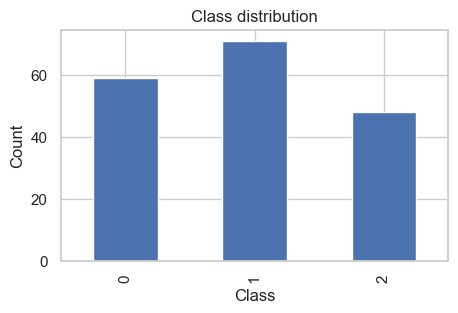

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [3]:
display(y.value_counts().sort_index().rename("count").to_frame())
y.value_counts().sort_index().plot(kind="bar", figsize=(5, 3), title="Class distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()

display(X.describe().T.head(13))

### Analytical interpretation

The class distribution is reasonably balanced, so macro and weighted metrics should be close. Still, class-wise analysis remains important because separability can differ by class.

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

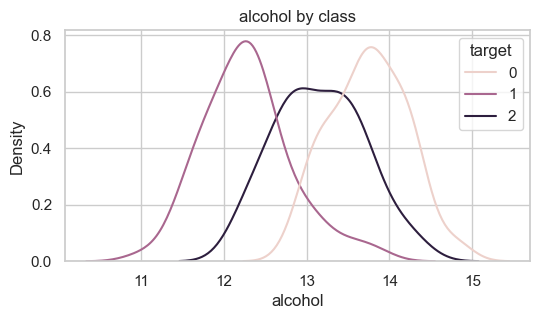

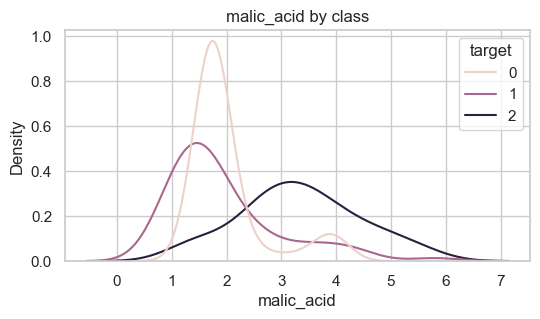

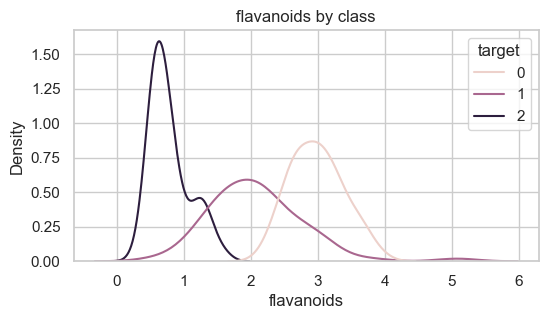

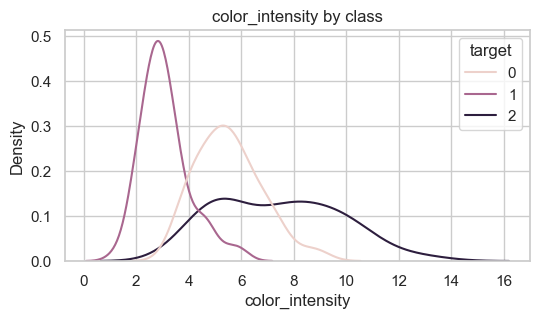

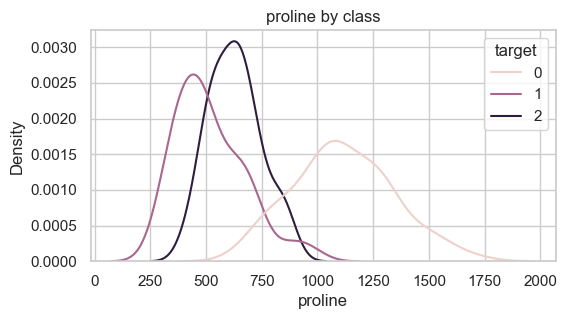

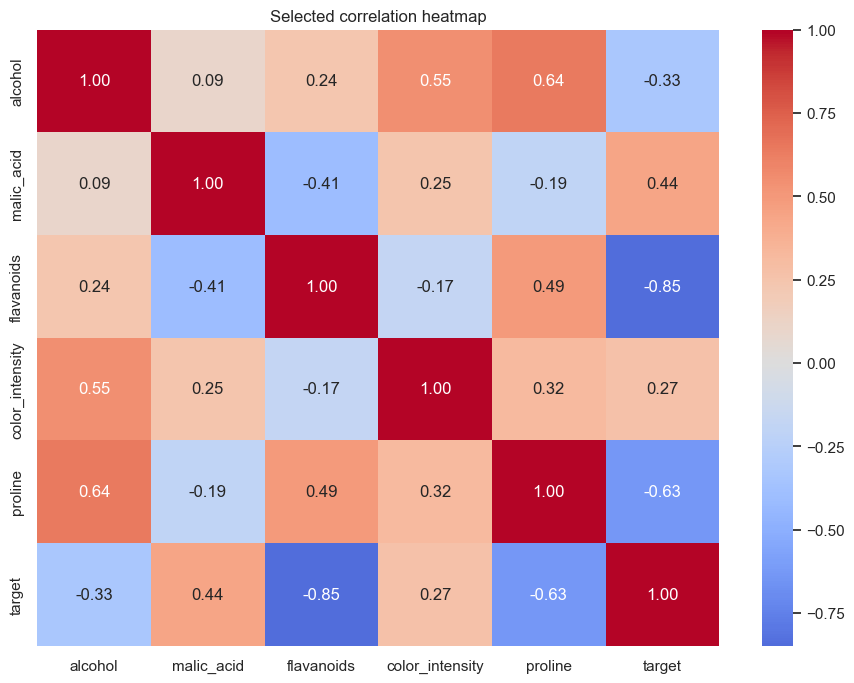

In [4]:
selected = ["alcohol", "malic_acid", "flavanoids", "color_intensity", "proline"]
for col in selected:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=df, x=col, hue="target", common_norm=False)
    plt.title(f"{col} by class")
    plt.show()

plt.figure(figsize=(11, 8))
sns.heatmap(df[selected + ["target"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Selected correlation heatmap")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

PCA projects the feature space into two dimensions for visualization. It does not prove class separability, but it helps reveal whether errors may occur near overlapping regions.

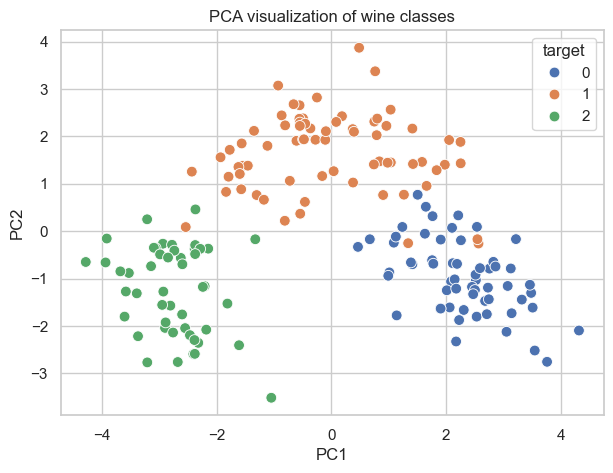

Explained variance ratio: [0.36198848 0.1920749 ]


In [5]:
pca_pipe = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=2, random_state=RANDOM_STATE))])
X_pca = pca_pipe.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y.values
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="target", palette="deep", s=60)
plt.title("PCA visualization of wine classes")
plt.show()
print("Explained variance ratio:", pca_pipe.named_steps["pca"].explained_variance_ratio_)

### Analytical interpretation

PCA visualization gives a geometric explanation for classification difficulty. Well-separated clusters suggest easier classification; overlapping regions suggest that even strong models may confuse nearby classes.

## Train/test split with stratification

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
print(X_train.shape, X_val.shape, X_test.shape)

(106, 13) (36, 13) (36, 13)


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

## Baseline model

The baseline model is fitted before any serious model. Its score defines the minimum level that later models must exceed to demonstrate that they have learned useful structure.

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.39      1.00      0.56        14
           2       0.00      0.00      0.00        10

    accuracy                           0.39        36
   macro avg       0.13      0.33      0.19        36
weighted avg       0.15      0.39      0.22        36



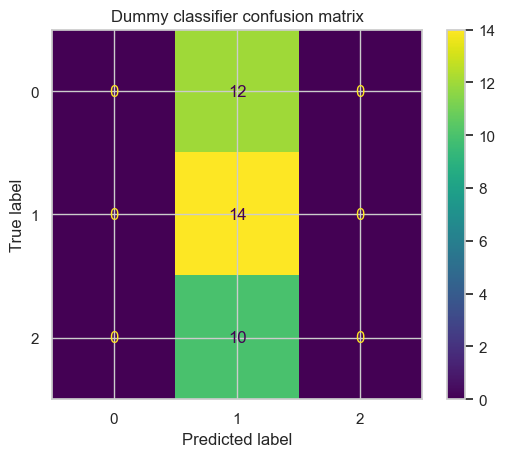

In [7]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred = dummy.predict(X_val)
print(classification_report(y_val, pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_val, pred)
plt.title("Dummy classifier confusion matrix")
plt.show()

### Analytical interpretation

The dummy classifier shows why baseline choice matters. In imbalanced classification, a majority-class rule can achieve deceptively high accuracy while producing very poor recall for the minority or positive class.

## KNN classifier: effect of K

Small `K` gives a local and flexible boundary; large `K` smooths the decision surface. Scaling is essential because KNN relies on distances.

KNN is evaluated across several neighbor counts. The train-validation pattern shows the transition from highly local memorization to smoother, possibly underfit boundaries.

split,train,validation
K,,
1,1.000000,0.948718
3,0.971763,0.974321
5,0.971763,0.974321
7,0.953215,1.000000
11,0.962986,1.000000
15,0.962986,1.000000
21,0.972845,1.000000


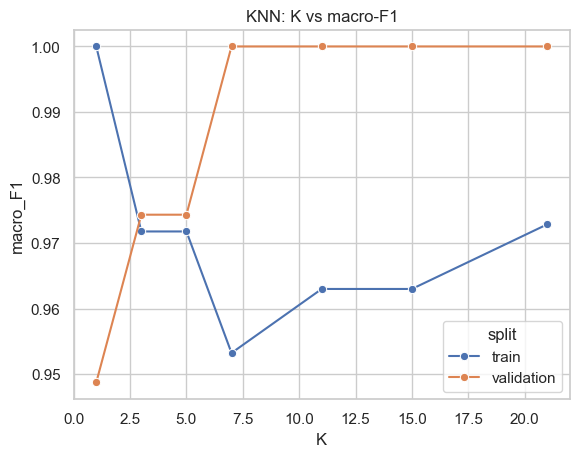

In [8]:
k_values = [1, 3, 5, 7, 11, 15, 21]
knn_rows = []
for k in k_values:
    model = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=k))])
    model.fit(X_train, y_train)
    for split, Xs, ys in [("train", X_train, y_train), ("validation", X_val, y_val)]:
        pred = model.predict(Xs)
        knn_rows.append({
            "K": k, "split": split,
            "accuracy": accuracy_score(ys, pred),
            "macro_F1": f1_score(ys, pred, average="macro")
        })
knn_df = pd.DataFrame(knn_rows)
display(knn_df.pivot(index="K", columns="split", values="macro_F1"))
sns.lineplot(data=knn_df, x="K", y="macro_F1", hue="split", marker="o")
plt.title("KNN: K vs macro-F1")
plt.show()

### Analytical interpretation

The KNN curve should show high flexibility at small `K` and smoother behavior at larger `K`. A useful `K` is not simply the one with the highest training accuracy; it is the value where validation accuracy or macro-F1 is strong and stable.

### Interpretation guide

Observe whether low `K` has high training performance but weaker validation performance. A good `K` should balance local detail and generalization.

## Logistic Regression: regularization effect

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

,C,coef_norm,train_macro_F1,val_macro_F1
0,0.001,0.127054,0.542114,0.427581
1,0.010,0.650618,0.990230,1.000000
2,0.100,1.611130,0.990230,1.000000
3,1.000,3.094901,1.000000,1.000000
4,10.000,5.244027,1.000000,1.000000
5,100.000,7.855787,1.000000,1.000000


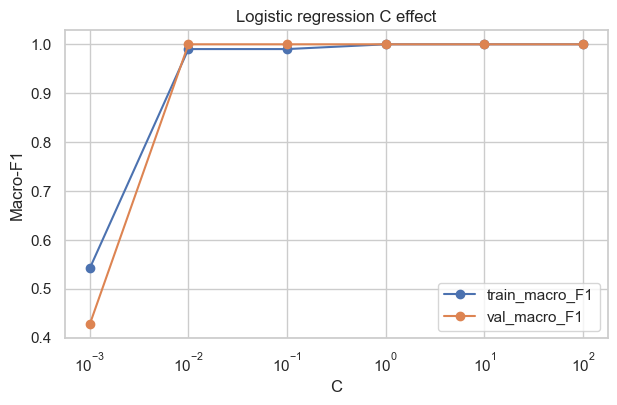

In [9]:
log_rows = []
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(C=C, max_iter=5000, multi_class="auto", random_state=RANDOM_STATE))])
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    coef_norm = np.linalg.norm(model.named_steps["model"].coef_)
    log_rows.append({"C": C, "coef_norm": coef_norm, "train_macro_F1": f1_score(y_train, train_pred, average="macro"), "val_macro_F1": f1_score(y_val, val_pred, average="macro")})
log_df = pd.DataFrame(log_rows)
display(log_df)
log_df.plot(x="C", y=["train_macro_F1", "val_macro_F1"], marker="o", logx=True, figsize=(7,4), title="Logistic regression C effect")
plt.ylabel("Macro-F1")
plt.show()

### Analytical interpretation

The logistic regression results show the effect of regularization strength. A middle `C` often balances coefficient flexibility and generalization, while very small `C` can underfit.

## SVM: linear vs RBF and hyperparameters

SVM hyperparameters are studied manually. Since SVMs depend on distances and margins, scaling and the choice of `C` and `gamma` strongly influence the learned boundary.

,model,accuracy,macro_F1
0,linear,1.000000,1.000000
1,rbf,0.972222,0.974013


,C,train_macro_F1,val_macro_F1
0,0.01,0.192394,0.186667
1,0.10,0.990108,0.945741
2,1.00,0.990230,0.974013
3,10.00,1.000000,0.974013
4,100.00,1.000000,0.974013


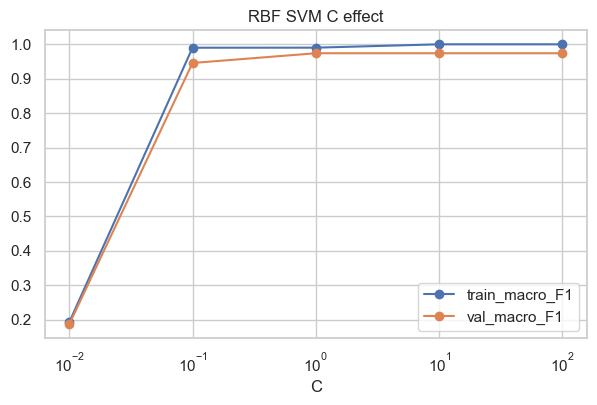

,gamma,train_macro_F1,val_macro_F1
0,0.001,0.591434,0.499883
1,0.010,0.990230,1.000000
2,0.100,1.000000,0.974013
3,1.000,1.000000,0.468806


In [10]:
svm_rows = []
svm_configs = [("linear", {"kernel":"linear", "C":1}), ("rbf", {"kernel":"rbf", "C":1, "gamma":"scale"})]
for name, params in svm_configs:
    model = Pipeline([("scaler", StandardScaler()), ("model", SVC(**params, probability=True, random_state=RANDOM_STATE))])
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    svm_rows.append({"model": name, "accuracy": accuracy_score(y_val, pred), "macro_F1": f1_score(y_val, pred, average="macro")})
display(pd.DataFrame(svm_rows))

rbf_rows = []
for C in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=C, gamma="scale", random_state=RANDOM_STATE))])
    model.fit(X_train, y_train)
    rbf_rows.append({"C": C, "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
rbf_df = pd.DataFrame(rbf_rows)
display(rbf_df)
rbf_df.plot(x="C", y=["train_macro_F1", "val_macro_F1"], marker="o", logx=True, figsize=(7,4), title="RBF SVM C effect")
plt.show()

gamma_rows = []
for gamma in [0.001, 0.01, 0.1, 1]:
    model = Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1, gamma=gamma, random_state=RANDOM_STATE))])
    model.fit(X_train, y_train)
    gamma_rows.append({"gamma": gamma, "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
display(pd.DataFrame(gamma_rows))

### Analytical interpretation

The SVM results should be interpreted through boundary complexity. Very small `C` or very small `gamma` can underfit; very large values can create overly local boundaries. A good setting balances margin flexibility with validation stability.

## Decision Tree: depth and leaf-size effects

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

In [11]:
tree_rows = []
for depth in [1, 2, 3, 4, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    tree_rows.append({"max_depth": str(depth), "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
display(pd.DataFrame(tree_rows))

leaf_rows = []
for leaf in [1, 3, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    leaf_rows.append({"min_samples_leaf": leaf, "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
display(pd.DataFrame(leaf_rows))

,max_depth,train_macro_F1,val_macro_F1
0,1,0.517949,0.525210
1,2,0.938300,0.922963
2,3,1.000000,0.922963
3,4,1.000000,0.922963
4,5,1.000000,0.922963
5,None,1.000000,0.922963


,min_samples_leaf,train_macro_F1,val_macro_F1
0,1,1.000000,0.922963
1,3,0.981569,0.948413
2,5,0.981569,0.948413
3,10,0.946289,0.920123


### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Random Forest and Gradient Boosting

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

In [12]:
rf_rows = []
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    start=time.time(); model.fit(X_train, y_train); runtime=time.time()-start
    rf_rows.append({"n_estimators": n, "runtime_sec": runtime, "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
display(pd.DataFrame(rf_rows))

gb_rows = []
for lr in [0.03, 0.1, 0.2]:
    for n in [25, 50, 100]:
        model = GradientBoostingClassifier(learning_rate=lr, n_estimators=n, max_depth=2, random_state=RANDOM_STATE)
        start=time.time(); model.fit(X_train, y_train); runtime=time.time()-start
        gb_rows.append({"learning_rate": lr, "n_estimators": n, "runtime_sec": runtime, "train_macro_F1": f1_score(y_train, model.predict(X_train), average="macro"), "val_macro_F1": f1_score(y_val, model.predict(X_val), average="macro")})
gb_df = pd.DataFrame(gb_rows)
display(gb_df.sort_values("val_macro_F1", ascending=False))

,n_estimators,runtime_sec,train_macro_F1,val_macro_F1
0,10,0.051683,1.0,0.974321
1,50,0.146948,1.0,1.000000
2,100,0.246329,1.0,1.000000
3,200,0.397417,1.0,1.000000


,learning_rate,n_estimators,runtime_sec,train_macro_F1,val_macro_F1
4,0.10,50,0.215407,1.0,1.000000
5,0.10,100,0.687933,1.0,1.000000
6,0.20,25,0.182826,1.0,1.000000
7,0.20,50,0.347009,1.0,1.000000
8,0.20,100,0.649880,1.0,1.000000
1,0.03,50,0.348548,1.0,0.974013
2,0.03,100,0.629436,1.0,0.974013
3,0.10,25,0.272297,1.0,0.974013
0,0.03,25,0.237140,1.0,0.947475


### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

## Model comparison

The baseline model is fitted before any serious model. Its score defines the minimum level that later models must exceed to demonstrate that they have learned useful structure.

In [13]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "KNN k=5": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]),
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(C=1, max_iter=5000, random_state=RANDOM_STATE))]),
    "SVM RBF": Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1, gamma="scale", probability=True, random_state=RANDOM_STATE))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.1, n_estimators=50, max_depth=2, random_state=RANDOM_STATE),
}
rows=[]
for name, model in models.items():
    start=time.time(); model.fit(X_train, y_train); runtime=time.time()-start
    pred=model.predict(X_test)
    rows.append({
        "Model": name, "runtime_sec": runtime,
        "accuracy": accuracy_score(y_test, pred),
        "macro_precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, pred, average="macro", zero_division=0),
        "macro_F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_F1": f1_score(y_test, pred, average="weighted", zero_division=0),
    })
comparison_df = pd.DataFrame(rows).sort_values("macro_F1", ascending=False)
display(comparison_df)

,Model,runtime_sec,accuracy,macro_precision,macro_recall,macro_F1,weighted_F1
1,KNN k=5,0.004896,1.000000,1.000000,1.000000,1.000000,1.000000
5,Random Forest,0.175303,1.000000,1.000000,1.000000,1.000000,1.000000
6,Gradient Boosting,0.219625,1.000000,1.000000,1.000000,1.000000,1.000000
2,Logistic Regression,0.013441,0.972222,0.977778,0.966667,0.970962,0.971970
3,SVM RBF,0.009487,0.972222,0.977778,0.966667,0.970962,0.971970
4,Decision Tree,0.000000,0.888889,0.901099,0.891270,0.894837,0.889825
0,Dummy,0.006278,0.388889,0.129630,0.333333,0.186667,0.217778


### Analytical interpretation

The dummy classifier shows why baseline choice matters. In imbalanced classification, a majority-class rule can achieve deceptively high accuracy while producing very poor recall for the minority or positive class.

## Confusion matrix and class-wise metrics

The classification report and confusion matrix break performance into error types. This is more informative than accuracy alone, especially when classes are imbalanced or specific mistakes are more costly.


 KNN k=5
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



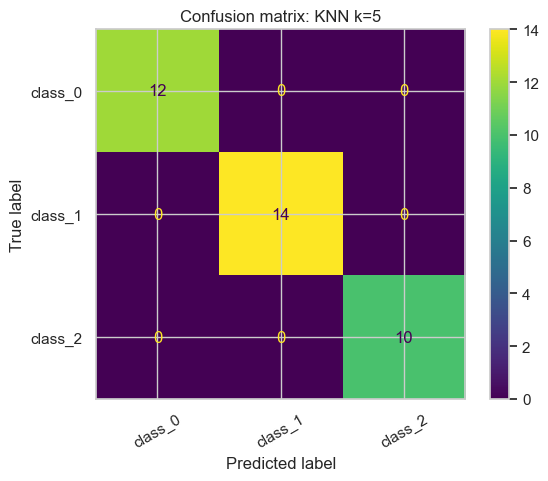

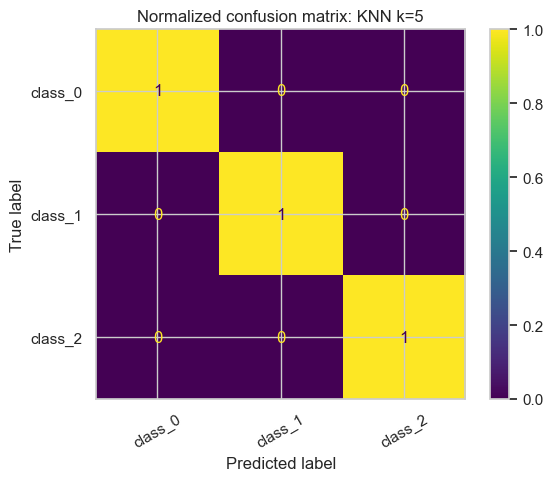


 Random Forest
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



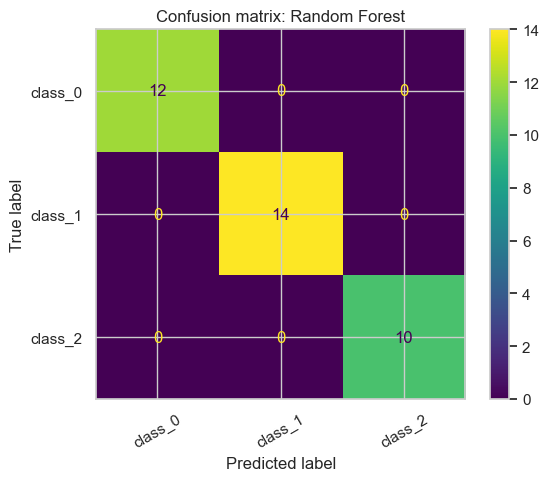

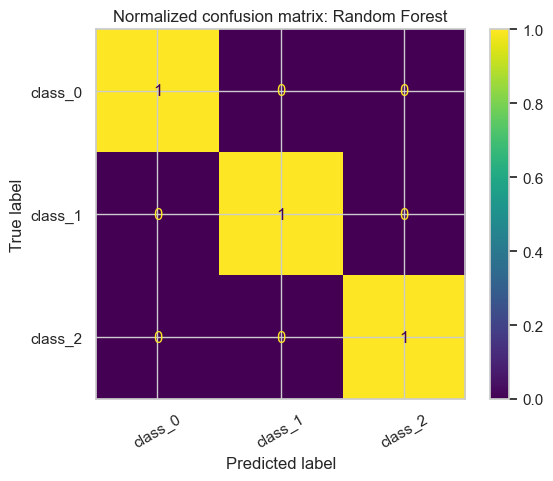


 Gradient Boosting
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



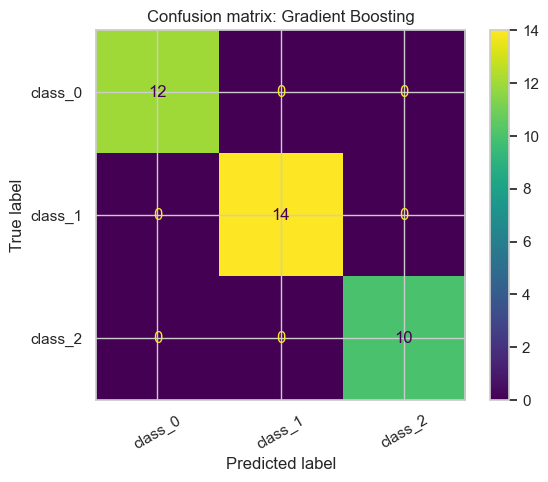

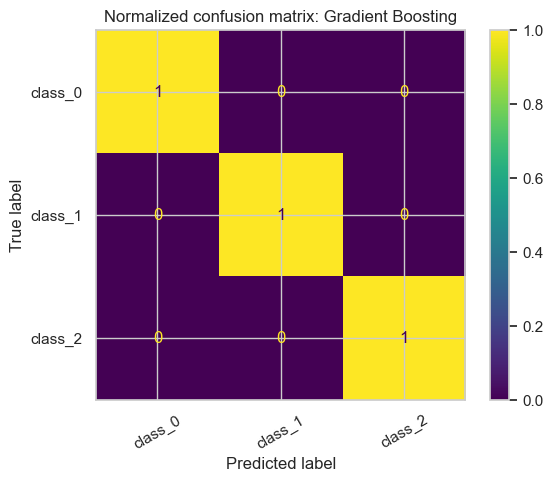

In [14]:
top_models = comparison_df["Model"].head(3).tolist()
for name in top_models:
    model = models[name]
    pred = model.predict(X_test)
    print("\n", name)
    print(classification_report(y_test, pred, target_names=wine.target_names, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=wine.target_names)
    plt.title(f"Confusion matrix: {name}")
    plt.xticks(rotation=30); plt.show()
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=wine.target_names, normalize="true")
    plt.title(f"Normalized confusion matrix: {name}")
    plt.xticks(rotation=30); plt.show()

### Analytical interpretation

The confusion matrix and report identify which class or error type drives the score. For imbalanced data, recall and precision for the positive/minority class are more informative than accuracy alone.

## Error analysis in PCA space

PCA projects the feature space into two dimensions for visualization. It does not prove class separability, but it helps reveal whether errors may occur near overlapping regions.

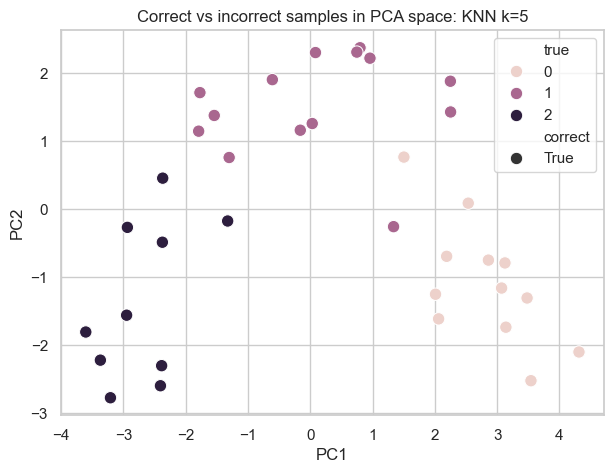

,PC1,PC2,true,pred,correct


In [15]:
best_name = comparison_df.iloc[0]["Model"]
best_model = models[best_name]
pred = best_model.predict(X_test)
X_test_pca = pca_pipe.transform(X_test)
err_df = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
err_df["true"] = y_test.values
err_df["pred"] = pred
err_df["correct"] = err_df["true"] == err_df["pred"]
plt.figure(figsize=(7, 5))
sns.scatterplot(data=err_df, x="PC1", y="PC2", hue="true", style="correct", s=80)
plt.title(f"Correct vs incorrect samples in PCA space: {best_name}")
plt.show()
display(err_df[~err_df["correct"]])

### Analytical interpretation

PCA visualization gives a geometric explanation for classification difficulty. Well-separated clusters suggest easier classification; overlapping regions suggest that even strong models may confuse nearby classes.

## Feature importance and coefficients

The learned coefficients are organized by magnitude. This gives an interpretable view of which standardized variables most strongly influence the linear prediction.

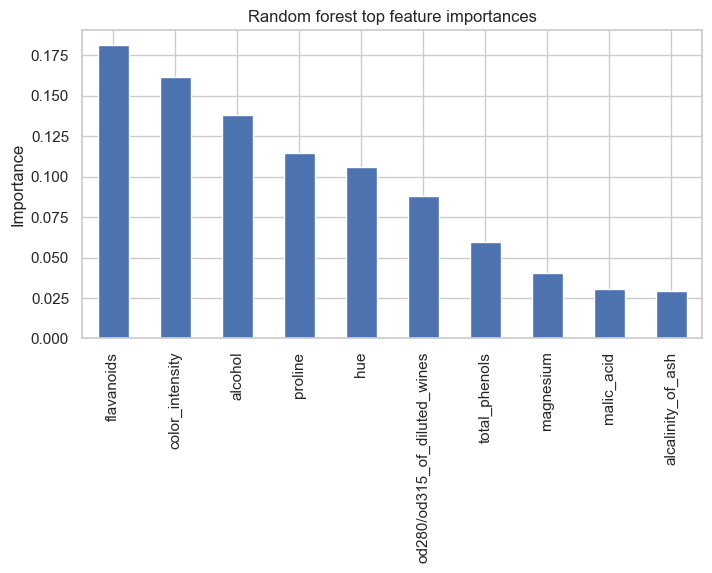

,class_0,class_1,class_2
proline,0.793264,-0.854721,0.061457
alcalinity_of_ash,-0.756209,0.473257,0.282952
alcohol,0.728820,-0.868356,0.139536
flavanoids,0.625750,0.168960,-0.794711
od280/od315_of_diluted_wines,0.622833,-0.104833,-0.518000
total_phenols,0.319061,0.070949,-0.390010
ash,0.218428,-0.619811,0.401383
malic_acid,0.215709,-0.521368,0.305659
nonflavanoid_phenols,-0.195447,0.195197,0.000250
color_intensity,0.188116,-1.049871,0.861755


In [16]:
rf = models["Random Forest"]
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_imp.head(10).plot(kind="bar", figsize=(8, 4), title="Random forest top feature importances")
plt.ylabel("Importance")
plt.show()

log_model = models["Logistic Regression"].named_steps["model"]
coef = pd.DataFrame(log_model.coef_, columns=X.columns, index=wine.target_names)
display(coef.T.sort_values(wine.target_names[0], key=abs, ascending=False).head(10))

### Analytical interpretation

Feature importance and coefficients give model-specific explanations. They are useful for interpretation, but they should not be treated as causal evidence because features are correlated and the dataset is observational.

## Additional analytical experiment: prediction confidence and class boundary errors

Multi-class errors are often associated with low confidence or small margins between the top two predicted probabilities. The following cell compares confidence for correct and incorrect predictions using the best model from the comparison table.

confidence                       top2_margin                      
             count      mean median  min       count      mean median  min
correct                                                                   
True            36  0.944444    1.0  0.6          36  0.888889    1.0  0.2

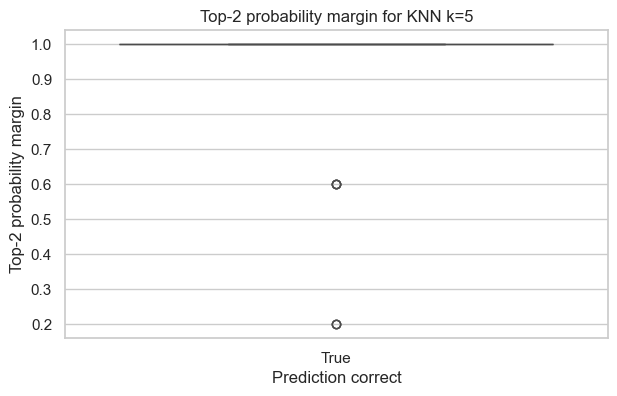

In [17]:
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_test)
    sorted_proba = np.sort(proba, axis=1)
    confidence = sorted_proba[:, -1]
    margin = sorted_proba[:, -1] - sorted_proba[:, -2]
    conf_df = pd.DataFrame({
        "true": y_test.values,
        "pred": y_pred_best,
        "correct": y_pred_best == y_test.values,
        "confidence": confidence,
        "top2_margin": margin
    })
    display(conf_df.groupby("correct")[["confidence", "top2_margin"]].agg(["count", "mean", "median", "min"]))
    
    plt.figure(figsize=(7,4))
    sns.boxplot(data=conf_df, x="correct", y="top2_margin")
    plt.title(f"Top-2 probability margin for {best_name}")
    plt.xlabel("Prediction correct")
    plt.ylabel("Top-2 probability margin")
    plt.show()
else:
    print(f"{best_name} does not expose predict_proba; use decision_function or choose a probabilistic model.")


### How to interpret this added experiment
If wrong predictions have lower confidence or smaller top-2 margins, many errors are boundary-like and uncertainty-aware decisions may help. If wrong predictions are highly confident, the model may be learning misleading patterns or the feature space may not represent those samples well.

## Interpretation

Use the confusion matrices and class-wise metrics to decide whether the model works uniformly across classes. Macro-F1 is useful when each class should matter equally; weighted-F1 is influenced more by larger classes.

## Limitations

- Wine is small, so validation estimates can be variable.
- PCA visualization is only a 2D projection and may hide separability in other dimensions.
- Feature importance does not imply causality.

## What we learned

This project covered multi-class models, KNN, logistic regression, SVM, trees, ensembles, macro/micro/weighted averaging, confusion matrices, PCA-based error analysis, and feature interpretation.

## Possible extensions

Try calibration for multi-class probabilities, one-vs-rest analysis, SHAP, imbalanced multi-class experiments, and a neural-network classifier.